In [11]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
!pip install -q wfdb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 68.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.5 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.5 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.5 which is incompatible.


In [13]:
!pip install -q "pandas==2.2.2" "wfdb==4.1.2"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 115.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.0/160.0 kB 17.4 MB/s eta 0:00:00


In [14]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import wfdb

from scipy.signal import resample_poly
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import GroupKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Pandas version:", pd.__version__)
print("WFDB version:", wfdb.__version__)
print("PyTorch version:", torch.__version__)
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Pandas version: 2.2.2
WFDB version: 4.1.2
PyTorch version: 2.11.0+cu128
Device: cuda
GPU: Tesla T4


In [15]:
project_dir = Path("/content/drive/MyDrive/cinc2025")
feature_csv_path = project_dir / "week5_ecg_features.csv"

zip_files = sorted(project_dir.glob("*.zip"))

print("Project folder exists:", project_dir.exists())
print("Feature CSV exists:", feature_csv_path.exists())
print("ZIP files found:", len(zip_files))

for zip_path in zip_files:
    size_gb = zip_path.stat().st_size / (1024 ** 3)
    print(f"- {zip_path.name}: {size_gb:.2f} GB")

if not feature_csv_path.exists():
    raise FileNotFoundError(
        "week5_ecg_features.csv was not found."
    )

if len(zip_files) == 0:
    raise FileNotFoundError(
        "No ZIP file was found in the cinc2025 folder."
    )

data_zip_path = zip_files[0]

print("\nSelected ZIP:", data_zip_path)

Project folder exists: True
Feature CSV exists: True
ZIP files found: 1
- data.zip: 2.70 GB

Selected ZIP: /content/drive/MyDrive/cinc2025/data.zip


In [16]:
feature_df = pd.read_csv(
    feature_csv_path,
    dtype={
        "record_id": str,
        "patient_id": str
    }
)

print("Dataset shape:", feature_df.shape)

print("\nRecords by dataset:")
print(feature_df["dataset"].value_counts())

print("\nLabels:")
print(feature_df["label"].value_counts())

print("\nUnique patients:")
print(feature_df["patient_id"].nunique())

print("\nSaMi-Trop sample record IDs:")
print(
    feature_df.loc[
        feature_df["dataset"] == "SaMi-Trop",
        "record_id"
    ].head().tolist()
)

print("\nPTB-XL sample record IDs:")
print(
    feature_df.loc[
        feature_df["dataset"] == "PTB-XL",
        "record_id"
    ].head().tolist()
)

Dataset shape: (2100, 15)

Records by dataset:
dataset
SaMi-Trop    1600
PTB-XL        500
Name: count, dtype: int64

Labels:
label
1    1600
0     500
Name: count, dtype: int64

Unique patients:
2099

SaMi-Trop sample record IDs:
['100726', '101191', '101193', '101282', '101842']

PTB-XL sample record IDs:
['16972_lr', '00740_lr', '15037_lr', '12823_lr', '05955_lr']


In [17]:
import zipfile
from pathlib import Path
from collections import Counter

with zipfile.ZipFile(data_zip_path, "r") as zip_file:
    zip_names = zip_file.namelist()

print("Files and folders inside ZIP:", len(zip_names))

suffix_counts = Counter(
    Path(name).suffix.lower()
    for name in zip_names
    if not name.endswith("/")
)

print("\nMost common file extensions:")
for suffix, count in suffix_counts.most_common(10):
    print(f"{suffix or '[no extension]'}: {count}")

print("\nFirst 20 ZIP entries:")
for name in zip_names[:20]:
    print(name)

Files and folders inside ZIP: 265020

Most common file extensions:
.dat: 132425
.hea: 132425
[no extension]: 74
.txt: 8
.csv: 6
.ds_store: 2
.hdf5: 2
.zip: 2
.py: 2
.3: 1

First 20 ZIP entries:
data/
__MACOSX/._data
data/.DS_Store
__MACOSX/data/._.DS_Store
data/ptbxl_wfdb/
__MACOSX/data/._ptbxl_wfdb
data/samitrop_wfdb/
data/samitrop_raw/
data/ptb-xl-1.0.3/
__MACOSX/data/._ptb-xl-1.0.3
data/ptbxl_wfdb/00000/
__MACOSX/data/ptbxl_wfdb/._00000
data/ptbxl_wfdb/10000/
__MACOSX/data/ptbxl_wfdb/._10000
data/ptbxl_wfdb/04000/
__MACOSX/data/ptbxl_wfdb/._04000
data/ptbxl_wfdb/14000/
__MACOSX/data/ptbxl_wfdb/._14000
data/ptbxl_wfdb/20000/
__MACOSX/data/ptbxl_wfdb/._20000


In [18]:
sample_records = (
    feature_df.groupby("dataset", group_keys=False)
    .head(5)[["dataset", "record_id"]]
)

for _, row in sample_records.iterrows():
    dataset = row["dataset"]
    record_id = str(row["record_id"])

    matches = [
        name
        for name in zip_names
        if not name.endswith("/")
        and Path(name).stem == record_id
        and Path(name).suffix.lower() in {".hea", ".dat"}
        and "__MACOSX" not in name
    ]

    print(f"\n{dataset} — {record_id}")
    print("Matches found:", len(matches))

    for match in matches:
        print(" ", match)


SaMi-Trop — 100726
Matches found: 2
  data/samitrop_wfdb/100726.dat
  data/samitrop_wfdb/100726.hea

SaMi-Trop — 101191
Matches found: 2
  data/samitrop_wfdb/101191.hea
  data/samitrop_wfdb/101191.dat

SaMi-Trop — 101193
Matches found: 2
  data/samitrop_wfdb/101193.hea
  data/samitrop_wfdb/101193.dat

SaMi-Trop — 101282
Matches found: 2
  data/samitrop_wfdb/101282.hea
  data/samitrop_wfdb/101282.dat

SaMi-Trop — 101842
Matches found: 2
  data/samitrop_wfdb/101842.dat
  data/samitrop_wfdb/101842.hea

PTB-XL — 16972_lr
Matches found: 4
  data/ptbxl_wfdb/16000/16972_lr.dat
  data/ptbxl_wfdb/16000/16972_lr.hea
  data/ptb-xl-1.0.3/records100/16000/16972_lr.dat
  data/ptb-xl-1.0.3/records100/16000/16972_lr.hea

PTB-XL — 00740_lr
Matches found: 4
  data/ptbxl_wfdb/00000/00740_lr.dat
  data/ptbxl_wfdb/00000/00740_lr.hea
  data/ptb-xl-1.0.3/records100/00000/00740_lr.dat
  data/ptb-xl-1.0.3/records100/00000/00740_lr.hea

PTB-XL — 15037_lr
Matches found: 4
  data/ptbxl_wfdb/15000/15037_lr.dat
  

In [19]:
from collections import defaultdict
from pathlib import Path

dataset_prefixes = {
    "SaMi-Trop": "data/samitrop_wfdb/",
    "PTB-XL": "data/ptbxl_wfdb/"
}

member_index = defaultdict(list)

for name in zip_names:
    if name.endswith("/") or "__MACOSX" in name:
        continue

    suffix = Path(name).suffix.lower()

    if suffix not in {".hea", ".dat"}:
        continue

    for dataset_name, prefix in dataset_prefixes.items():
        if name.startswith(prefix):
            key = (
                dataset_name,
                Path(name).stem,
                suffix
            )
            member_index[key].append(name)
            break

records_to_extract = []
missing_files = []
duplicate_files = []

for row in feature_df[
    ["dataset", "record_id"]
].itertuples(index=False):

    dataset_name = row.dataset
    record_id = str(row.record_id)

    selected_files = {}

    for suffix in [".hea", ".dat"]:
        matches = member_index.get(
            (dataset_name, record_id, suffix),
            []
        )

        if len(matches) == 0:
            missing_files.append(
                (dataset_name, record_id, suffix)
            )

        elif len(matches) > 1:
            duplicate_files.append(
                (dataset_name, record_id, suffix, matches)
            )

        else:
            selected_files[suffix] = matches[0]

    if len(selected_files) == 2:
        records_to_extract.append({
            "dataset": dataset_name,
            "record_id": record_id,
            ".hea": selected_files[".hea"],
            ".dat": selected_files[".dat"]
        })

print("Rows in feature table:", len(feature_df))
print("Complete records found:", len(records_to_extract))
print("Missing files:", len(missing_files))
print("Duplicate files in selected folders:", len(duplicate_files))

if missing_files:
    print("\nFirst missing files:")
    for item in missing_files[:10]:
        print(item)

if duplicate_files:
    print("\nFirst duplicate files:")
    for item in duplicate_files[:5]:
        print(item)

assert len(missing_files) == 0, (
    "Some required ECG files are missing."
)

assert len(records_to_extract) == len(feature_df), (
    "The number of matched records is incorrect."
)

print("\nAll required ECG records were found.")

Rows in feature table: 2100
Complete records found: 2100
Missing files: 0
Duplicate files in selected folders: 0

All required ECG records were found.


In [20]:
import shutil
import zipfile
from tqdm.auto import tqdm

subset_root = Path("/content/ecg_subset")

if subset_root.exists():
    shutil.rmtree(subset_root)

(subset_root / "samitrop").mkdir(
    parents=True,
    exist_ok=True
)

(subset_root / "ptbxl").mkdir(
    parents=True,
    exist_ok=True
)

with zipfile.ZipFile(data_zip_path, "r") as zip_file:

    for record in tqdm(
        records_to_extract,
        desc="Extracting ECG records"
    ):
        dataset_name = record["dataset"]
        record_id = record["record_id"]

        output_folder = (
            subset_root / "samitrop"
            if dataset_name == "SaMi-Trop"
            else subset_root / "ptbxl"
        )

        for suffix in [".hea", ".dat"]:
            source_name = record[suffix]
            destination = (
                output_folder / f"{record_id}{suffix}"
            )

            with zip_file.open(
                source_name
            ) as source_file:
                with open(
                    destination,
                    "wb"
                ) as destination_file:
                    shutil.copyfileobj(
                        source_file,
                        destination_file
                    )

samitrop_headers = list(
    (subset_root / "samitrop").glob("*.hea")
)

ptbxl_headers = list(
    (subset_root / "ptbxl").glob("*.hea")
)

print("\nExtracted SaMi-Trop records:", len(samitrop_headers))
print("Extracted PTB-XL records:", len(ptbxl_headers))
print(
    "Total extracted records:",
    len(samitrop_headers) + len(ptbxl_headers)
)

Extracting ECG records:   0%|          | 0/2100 [00:00<?, ?it/s]


Extracted SaMi-Trop records: 1600
Extracted PTB-XL records: 500
Total extracted records: 2100


In [21]:
def make_record_path(row):
    if row["dataset"] == "SaMi-Trop":
        folder = subset_root / "samitrop"
    else:
        folder = subset_root / "ptbxl"

    return str(folder / str(row["record_id"]))


feature_df["record_path"] = feature_df.apply(
    make_record_path,
    axis=1
)

path_check = feature_df["record_path"].apply(
    lambda path: Path(path + ".hea").exists()
    and Path(path + ".dat").exists()
)

print("Records with both files:", path_check.sum())
print("Records missing a file:", (~path_check).sum())

print("\nExample record paths:")
print(
    feature_df[
        ["dataset", "record_id", "record_path"]
    ].head()
)

Records with both files: 2100
Records missing a file: 0

Example record paths:
     dataset record_id                          record_path
0  SaMi-Trop    100726  /content/ecg_subset/samitrop/100726
1  SaMi-Trop    101191  /content/ecg_subset/samitrop/101191
2  SaMi-Trop    101193  /content/ecg_subset/samitrop/101193
3  SaMi-Trop    101282  /content/ecg_subset/samitrop/101282
4  SaMi-Trop    101842  /content/ecg_subset/samitrop/101842


In [22]:
for dataset_name in ["SaMi-Trop", "PTB-XL"]:

    sample_row = feature_df.loc[
        feature_df["dataset"] == dataset_name
    ].iloc[0]

    signal, fields = wfdb.rdsamp(
        sample_row["record_path"]
    )

    print("\nDataset:", dataset_name)
    print("Record ID:", sample_row["record_id"])
    print("Signal shape:", signal.shape)
    print("Sampling frequency:", fields["fs"])
    print("Lead names:", fields["sig_name"])


Dataset: SaMi-Trop
Record ID: 100726
Signal shape: (2934, 12)
Sampling frequency: 400
Lead names: ['I', 'II', 'III', 'AVR', 'AVL', 'AVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']

Dataset: PTB-XL
Record ID: 16972_lr
Signal shape: (1000, 12)
Sampling frequency: 100
Lead names: ['I', 'II', 'III', 'AVR', 'AVL', 'AVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']


In [23]:
from math import gcd

TARGET_FS = 100
TARGET_SECONDS = 7
TARGET_LENGTH = TARGET_FS * TARGET_SECONDS


def load_preprocessed_lead_ii(record_path):
    """
    Load Lead II, resample to 100 Hz, select a centered
    7-second segment, and apply per-record normalization.
    """
    header = wfdb.rdheader(record_path)

    lead_names = [
        str(name).strip().upper()
        for name in header.sig_name
    ]

    if "II" not in lead_names:
        raise ValueError(
            f"Lead II was not found in {record_path}. "
            f"Available leads: {header.sig_name}"
        )

    lead_index = lead_names.index("II")

    signal, fields = wfdb.rdsamp(
        record_path,
        channels=[lead_index]
    )

    lead_ii = signal[:, 0].astype(np.float32)
    original_fs = int(round(float(fields["fs"])))

    # Replace invalid values if any are present
    if not np.isfinite(lead_ii).all():
        finite_values = lead_ii[np.isfinite(lead_ii)]

        replacement = (
            np.median(finite_values)
            if len(finite_values) > 0
            else 0.0
        )

        lead_ii = np.nan_to_num(
            lead_ii,
            nan=replacement,
            posinf=replacement,
            neginf=replacement
        )

    # Resample only when necessary
    if original_fs != TARGET_FS:
        common_divisor = gcd(original_fs, TARGET_FS)

        up = TARGET_FS // common_divisor
        down = original_fs // common_divisor

        lead_ii = resample_poly(
            lead_ii,
            up,
            down
        ).astype(np.float32)

    # Center crop if longer than 7 seconds
    if len(lead_ii) > TARGET_LENGTH:
        start = (len(lead_ii) - TARGET_LENGTH) // 2
        lead_ii = lead_ii[
            start:start + TARGET_LENGTH
        ]

    # Zero-pad symmetrically if shorter
    elif len(lead_ii) < TARGET_LENGTH:
        total_padding = TARGET_LENGTH - len(lead_ii)
        left_padding = total_padding // 2
        right_padding = total_padding - left_padding

        lead_ii = np.pad(
            lead_ii,
            (left_padding, right_padding),
            mode="constant"
        )

    # Per-record z-score normalization
    mean = lead_ii.mean()
    std = lead_ii.std()

    lead_ii = (
        (lead_ii - mean) / (std + 1e-8)
    ).astype(np.float32)

    return lead_ii

In [24]:
processed_examples = {}

for dataset_name in ["SaMi-Trop", "PTB-XL"]:

    sample_row = feature_df.loc[
        feature_df["dataset"] == dataset_name
    ].iloc[0]

    processed_signal = load_preprocessed_lead_ii(
        sample_row["record_path"]
    )

    processed_examples[dataset_name] = processed_signal

    print("\nDataset:", dataset_name)
    print("Record ID:", sample_row["record_id"])
    print("Processed shape:", processed_signal.shape)
    print("Mean:", round(float(processed_signal.mean()), 4))
    print("Standard deviation:", round(float(processed_signal.std()), 4))
    print(
        "Contains invalid values:",
        not np.isfinite(processed_signal).all()
    )


Dataset: SaMi-Trop
Record ID: 100726
Processed shape: (700,)
Mean: -0.0
Standard deviation: 1.0
Contains invalid values: False

Dataset: PTB-XL
Record ID: 16972_lr
Processed shape: (700,)
Mean: 0.0
Standard deviation: 1.0
Contains invalid values: False


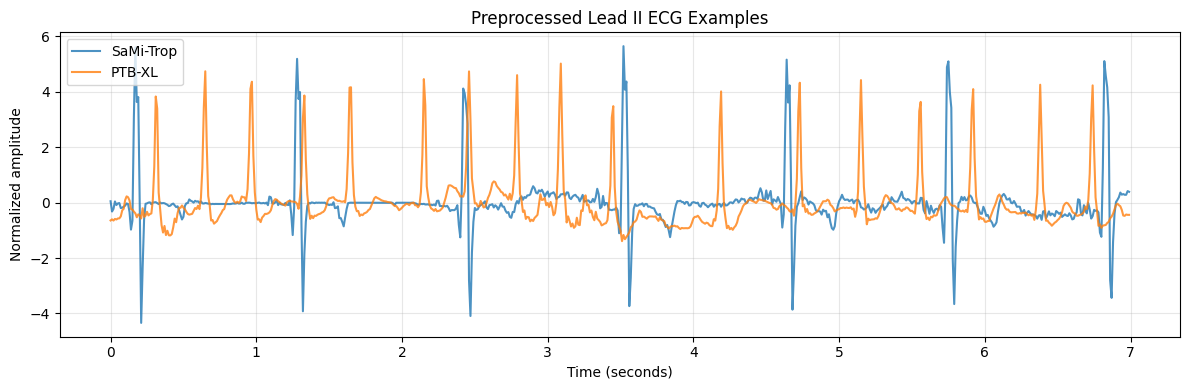

In [25]:
time_axis = np.arange(TARGET_LENGTH) / TARGET_FS

plt.figure(figsize=(12, 4))

for dataset_name, signal in processed_examples.items():
    plt.plot(
        time_axis,
        signal,
        label=dataset_name,
        alpha=0.8
    )

plt.xlabel("Time (seconds)")
plt.ylabel("Normalized amplitude")
plt.title("Preprocessed Lead II ECG Examples")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [26]:
class ECGDataset(Dataset):
    def __init__(self, dataframe):
        self.dataframe = dataframe.reset_index(drop=True)

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]

        signal = load_preprocessed_lead_ii(
            row["record_path"]
        )

        # CNN input format:
        # channels × signal length
        signal_tensor = torch.from_numpy(
            signal
        ).unsqueeze(0)

        label_tensor = torch.tensor(
            float(row["label"]),
            dtype=torch.float32
        )

        return signal_tensor, label_tensor

In [27]:
group_kfold = GroupKFold(n_splits=5)

fold_splits = list(
    group_kfold.split(
        feature_df,
        y=feature_df["label"],
        groups=feature_df["patient_id"]
    )
)

for fold_number, (train_indices, val_indices) in enumerate(
    fold_splits,
    start=1
):
    train_fold = feature_df.iloc[train_indices]
    val_fold = feature_df.iloc[val_indices]

    train_patients = set(train_fold["patient_id"])
    val_patients = set(val_fold["patient_id"])

    patient_overlap = len(
        train_patients.intersection(val_patients)
    )

    print(f"\nFold {fold_number}")
    print("Training records:", len(train_fold))
    print("Validation records:", len(val_fold))
    print(
        "Training labels:",
        train_fold["label"].value_counts().to_dict()
    )
    print(
        "Validation labels:",
        val_fold["label"].value_counts().to_dict()
    )
    print("Patient overlap:", patient_overlap)


Fold 1
Training records: 1680
Validation records: 420
Training labels: {1: 1281, 0: 399}
Validation labels: {1: 319, 0: 101}
Patient overlap: 0

Fold 2
Training records: 1680
Validation records: 420
Training labels: {1: 1278, 0: 402}
Validation labels: {1: 322, 0: 98}
Patient overlap: 0

Fold 3
Training records: 1680
Validation records: 420
Training labels: {1: 1280, 0: 400}
Validation labels: {1: 320, 0: 100}
Patient overlap: 0

Fold 4
Training records: 1680
Validation records: 420
Training labels: {1: 1282, 0: 398}
Validation labels: {1: 318, 0: 102}
Patient overlap: 0

Fold 5
Training records: 1680
Validation records: 420
Training labels: {1: 1279, 0: 401}
Validation labels: {1: 321, 0: 99}
Patient overlap: 0


In [28]:
BATCH_SIZE = 64

first_train_indices, first_val_indices = fold_splits[0]

first_train_df = feature_df.iloc[
    first_train_indices
].reset_index(drop=True)

first_val_df = feature_df.iloc[
    first_val_indices
].reset_index(drop=True)

first_train_dataset = ECGDataset(first_train_df)
first_val_dataset = ECGDataset(first_val_df)

first_train_loader = DataLoader(
    first_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

first_val_loader = DataLoader(
    first_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

batch_signals, batch_labels = next(
    iter(first_train_loader)
)

print("Signal batch shape:", batch_signals.shape)
print("Label batch shape:", batch_labels.shape)
print("Signal data type:", batch_signals.dtype)
print("Label data type:", batch_labels.dtype)
print(
    "Labels in first batch:",
    batch_labels.unique().tolist()
)
print(
    "All signal values finite:",
    torch.isfinite(batch_signals).all().item()
)

Signal batch shape: torch.Size([64, 1, 700])
Label batch shape: torch.Size([64])
Signal data type: torch.float32
Label data type: torch.float32
Labels in first batch: [0.0, 1.0]
All signal values finite: True


In [29]:
cache_path = (
    project_dir /
    "week7_leadII_100hz_7s.npy"
)

expected_shape = (
    len(feature_df),
    1,
    TARGET_LENGTH
)

rebuild_cache = True

if cache_path.exists():
    cached_signals = np.load(cache_path)

    if cached_signals.shape == expected_shape:
        all_signals = cached_signals.astype(
            np.float32,
            copy=False
        )
        rebuild_cache = False
        print("Loaded existing signal cache.")
    else:
        print(
            "Existing cache has the wrong shape:",
            cached_signals.shape
        )

if rebuild_cache:
    all_signals = np.empty(
        expected_shape,
        dtype=np.float32
    )

    for index, row in tqdm(
        feature_df.iterrows(),
        total=len(feature_df),
        desc="Preprocessing ECG signals"
    ):
        all_signals[index, 0, :] = (
            load_preprocessed_lead_ii(
                row["record_path"]
            )
        )

    np.save(cache_path, all_signals)
    print("Created and saved signal cache.")

all_labels = feature_df[
    "label"
].to_numpy(dtype=np.float32)

print("Signal array shape:", all_signals.shape)
print("Label array shape:", all_labels.shape)
print(
    "Approximate signal memory:",
    f"{all_signals.nbytes / (1024 ** 2):.2f} MB"
)
print(
    "All signals finite:",
    np.isfinite(all_signals).all()
)
print(
    "Labels:",
    dict(zip(*np.unique(
        all_labels,
        return_counts=True
    )))
)


Loaded existing signal cache.
Signal array shape: (2100, 1, 700)
Label array shape: (2100,)
Approximate signal memory: 5.61 MB
All signals finite: True
Labels: {np.float32(0.0): np.int64(500), np.float32(1.0): np.int64(1600)}


In [30]:
class CachedECGDataset(Dataset):
    def __init__(self, signals, labels, indices):
        self.signals = signals
        self.labels = labels
        self.indices = np.asarray(
            indices,
            dtype=np.int64
        )

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, index):
        record_index = self.indices[index]

        signal_tensor = torch.from_numpy(
            self.signals[record_index]
        )

        label_tensor = torch.tensor(
            self.labels[record_index],
            dtype=torch.float32
        )

        return signal_tensor, label_tensor


first_train_indices, first_val_indices = fold_splits[0]

first_train_dataset = CachedECGDataset(
    all_signals,
    all_labels,
    first_train_indices
)

first_val_dataset = CachedECGDataset(
    all_signals,
    all_labels,
    first_val_indices
)

first_train_loader = DataLoader(
    first_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

first_val_loader = DataLoader(
    first_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

batch_signals, batch_labels = next(
    iter(first_train_loader)
)

print("Training dataset size:", len(first_train_dataset))
print("Validation dataset size:", len(first_val_dataset))
print("Signal batch shape:", batch_signals.shape)
print("Label batch shape:", batch_labels.shape)

Training dataset size: 1680
Validation dataset size: 420
Signal batch shape: torch.Size([64, 1, 700])
Label batch shape: torch.Size([64])


In [31]:
class ECG1DCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv1d(
                in_channels=1,
                out_channels=16,
                kernel_size=7,
                padding=3
            ),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),

            nn.Conv1d(
                in_channels=16,
                out_channels=32,
                kernel_size=5,
                padding=2
            ),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),

            nn.Conv1d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),

            nn.AdaptiveAvgPool1d(1)
        )

        self.output_layer = nn.Linear(
            in_features=64,
            out_features=1
        )

    def forward(self, x):
        x = self.features(x)
        x = x.flatten(start_dim=1)
        x = self.output_layer(x)

        return x.squeeze(1)


test_model = ECG1DCNN().to(device)

with torch.no_grad():
    test_output = test_model(
        batch_signals.to(device)
    )

parameter_count = sum(
    parameter.numel()
    for parameter in test_model.parameters()
    if parameter.requires_grad
)

print(test_model)
print("\nModel output shape:", test_output.shape)
print("Trainable parameters:", parameter_count)

ECG1DCNN(
  (features): Sequential(
    (0): Conv1d(1, 16, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): ReLU()
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv1d(16, 32, kernel_size=(5,), stride=(1,), padding=(2,))
    (4): ReLU()
    (5): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (7): ReLU()
    (8): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): AdaptiveAvgPool1d(output_size=1)
  )
  (output_layer): Linear(in_features=64, out_features=1, bias=True)
)

Model output shape: torch.Size([64])
Trainable parameters: 8993


In [32]:
def challenge_score(
    y_true,
    probabilities,
    alpha=0.05
):
    y_true = np.asarray(y_true)
    probabilities = np.asarray(probabilities)

    number_selected = int(
        np.floor(alpha * len(y_true))
    )

    if number_selected == 0:
        return 0.0

    sorted_probabilities = np.sort(
        probabilities
    )[::-1]

    cutoff_probability = (
        sorted_probabilities[
            number_selected - 1
        ]
    )

    above_cutoff = (
        probabilities > cutoff_probability
    )

    tied_at_cutoff = (
        probabilities == cutoff_probability
    )

    selected_above = above_cutoff.sum()
    remaining_places = (
        number_selected - selected_above
    )

    positives_above = y_true[
        above_cutoff
    ].sum()

    number_tied = tied_at_cutoff.sum()
    positives_tied = y_true[
        tied_at_cutoff
    ].sum()

    expected_tied_positives = (
        remaining_places *
        positives_tied /
        number_tied
    )

    total_positives = y_true.sum()

    return (
        positives_above +
        expected_tied_positives
    ) / total_positives


def calculate_metrics(
    y_true,
    probabilities,
    threshold=0.5
):
    y_true = np.asarray(
        y_true,
        dtype=int
    )

    probabilities = np.asarray(
        probabilities,
        dtype=float
    )

    predictions = (
        probabilities >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        predictions,
        labels=[0, 1]
    ).ravel()

    sensitivity = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else 0.0
    )

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0.0
    )

    return {
        "Accuracy": accuracy_score(
            y_true,
            predictions
        ),
        "Precision": precision_score(
            y_true,
            predictions,
            zero_division=0
        ),
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "F1": f1_score(
            y_true,
            predictions,
            zero_division=0
        ),
        "AUROC": roc_auc_score(
            y_true,
            probabilities
        ),
        "Challenge Score": challenge_score(
            y_true,
            probabilities
        )
    }

In [33]:
def create_fold_loaders(
    train_indices,
    val_indices,
    batch_size=BATCH_SIZE,
    fold_seed=SEED
):
    train_dataset = CachedECGDataset(
        all_signals,
        all_labels,
        train_indices
    )

    val_dataset = CachedECGDataset(
        all_signals,
        all_labels,
        val_indices
    )

    generator = torch.Generator()
    generator.manual_seed(fold_seed)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
        generator=generator
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available()
    )

    return train_loader, val_loader


def evaluate_model(
    model,
    data_loader,
    criterion
):
    model.eval()

    total_loss = 0.0
    all_probabilities = []
    all_targets = []

    with torch.no_grad():
        for signals, targets in data_loader:
            signals = signals.to(
                device,
                non_blocking=True
            )

            targets = targets.to(
                device,
                non_blocking=True
            )

            logits = model(signals)
            loss = criterion(logits, targets)

            total_loss += (
                loss.item() * len(targets)
            )

            probabilities = torch.sigmoid(
                logits
            )

            all_probabilities.extend(
                probabilities.cpu().numpy()
            )

            all_targets.extend(
                targets.cpu().numpy()
            )

    average_loss = (
        total_loss /
        len(data_loader.dataset)
    )

    return (
        average_loss,
        np.asarray(all_targets),
        np.asarray(all_probabilities)
    )


def train_one_fold(
    train_indices,
    val_indices,
    fold_number,
    epochs=15,
    learning_rate=0.001
):
    torch.manual_seed(SEED + fold_number)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(
            SEED + fold_number
        )

    train_loader, val_loader = (
        create_fold_loaders(
            train_indices,
            val_indices,
            fold_seed=SEED + fold_number
        )
    )

    model = ECG1DCNN().to(device)

    train_fold_labels = all_labels[
        train_indices
    ]

    positive_count = float(
        np.sum(train_fold_labels == 1)
    )

    negative_count = float(
        np.sum(train_fold_labels == 0)
    )

    positive_weight = (
        negative_count / positive_count
    )

    criterion = nn.BCEWithLogitsLoss(
        pos_weight=torch.tensor(
            [positive_weight],
            dtype=torch.float32,
            device=device
        )
    )

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate
    )

    history = {
        "train_loss": [],
        "val_loss": []
    }

    best_val_loss = float("inf")
    best_epoch = 0
    best_state = None

    for epoch in range(1, epochs + 1):
        model.train()
        total_train_loss = 0.0

        for signals, targets in train_loader:
            signals = signals.to(
                device,
                non_blocking=True
            )

            targets = targets.to(
                device,
                non_blocking=True
            )

            optimizer.zero_grad()

            logits = model(signals)
            loss = criterion(logits, targets)

            loss.backward()
            optimizer.step()

            total_train_loss += (
                loss.item() * len(targets)
            )

        train_loss = (
            total_train_loss /
            len(train_loader.dataset)
        )

        val_loss, _, _ = evaluate_model(
            model,
            val_loader,
            criterion
        )

        history["train_loss"].append(
            train_loss
        )

        history["val_loss"].append(
            val_loss
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch

            best_state = {
                name: parameter.detach()
                .cpu()
                .clone()
                for name, parameter
                in model.state_dict().items()
            }

        print(
            f"Fold {fold_number} | "
            f"Epoch {epoch:02d}/{epochs} | "
            f"Train loss: {train_loss:.4f} | "
            f"Validation loss: {val_loss:.4f}"
        )

    model.load_state_dict(best_state)

    final_val_loss, y_true, probabilities = (
        evaluate_model(
            model,
            val_loader,
            criterion
        )
    )

    metrics = calculate_metrics(
        y_true,
        probabilities
    )

    return {
        "model": model,
        "history": history,
        "metrics": metrics,
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "y_true": y_true,
        "probabilities": probabilities
    }

In [34]:
smoke_test_result = train_one_fold(
    first_train_indices,
    first_val_indices,
    fold_number=1,
    epochs=1
)

print(
    "\nBest epoch:",
    smoke_test_result["best_epoch"]
)

print("\nSmoke-test validation metrics:")

for metric, value in (
    smoke_test_result["metrics"].items()
):
    print(f"{metric}: {value:.4f}")

Fold 1 | Epoch 01/1 | Train loss: 0.3257 | Validation loss: 0.3178

Best epoch: 1

Smoke-test validation metrics:
Accuracy: 0.4762
Precision: 0.9806
Sensitivity: 0.3166
Specificity: 0.9802
F1: 0.4787
AUROC: 0.7943
Challenge Score: 0.0658


In [38]:
import pickle

EPOCHS = 15
LEARNING_RATE = 0.001

fold_results = []

oof_probabilities = np.full(
    len(feature_df),
    np.nan,
    dtype=np.float32
)

oof_targets = all_labels.astype(int)

for fold_number, (
    train_indices,
    val_indices
) in enumerate(fold_splits, start=1):

    print(f"\nTraining fold {fold_number}/5")

    result = train_one_fold(
        train_indices=train_indices,
        val_indices=val_indices,
        fold_number=fold_number,
        epochs=EPOCHS,
        learning_rate=LEARNING_RATE
    )

    oof_probabilities[val_indices] = (
        result["probabilities"]
    )

    print(
        f"\nFold {fold_number} best epoch:",
        result["best_epoch"]
    )

    print(
        f"Fold {fold_number} best validation loss:",
        f"{result['best_val_loss']:.4f}"
    )

    print(f"\nFold {fold_number} metrics:")

    for metric, value in result["metrics"].items():
        print(f"{metric}: {value:.4f}")

    # Remove the trained model after evaluation
    # to reduce memory usage.
    trained_model = result.pop("model")
    del trained_model

    fold_results.append(result)

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

assert np.isfinite(oof_probabilities).all(), (
    "Some validation predictions are missing."
)

saved_training_results = {
    "fold_results": fold_results,
    "oof_probabilities": oof_probabilities,
    "oof_targets": oof_targets,
    "epochs": EPOCHS
}

training_results_path = (
    project_dir /
    "week7_cnn_training_results.pkl"
)

with open(training_results_path, "wb") as file:
    pickle.dump(saved_training_results, file)

print("\nFive-fold CNN training complete.")

print("\nTraining results saved to:")
print(training_results_path)


Training fold 1/5
Fold 1 | Epoch 01/15 | Train loss: 0.3257 | Validation loss: 0.3178
Fold 1 | Epoch 02/15 | Train loss: 0.3075 | Validation loss: 0.2878
Fold 1 | Epoch 03/15 | Train loss: 0.2813 | Validation loss: 0.2692
Fold 1 | Epoch 04/15 | Train loss: 0.2761 | Validation loss: 0.2581
Fold 1 | Epoch 05/15 | Train loss: 0.2692 | Validation loss: 0.2514
Fold 1 | Epoch 06/15 | Train loss: 0.2672 | Validation loss: 0.2512
Fold 1 | Epoch 07/15 | Train loss: 0.2602 | Validation loss: 0.2460
Fold 1 | Epoch 08/15 | Train loss: 0.2587 | Validation loss: 0.2567
Fold 1 | Epoch 09/15 | Train loss: 0.2568 | Validation loss: 0.2436
Fold 1 | Epoch 10/15 | Train loss: 0.2593 | Validation loss: 0.2538
Fold 1 | Epoch 11/15 | Train loss: 0.2522 | Validation loss: 0.2688
Fold 1 | Epoch 12/15 | Train loss: 0.2688 | Validation loss: 0.2365
Fold 1 | Epoch 13/15 | Train loss: 0.2496 | Validation loss: 0.2380
Fold 1 | Epoch 14/15 | Train loss: 0.2452 | Validation loss: 0.2293
Fold 1 | Epoch 15/15 | Train 

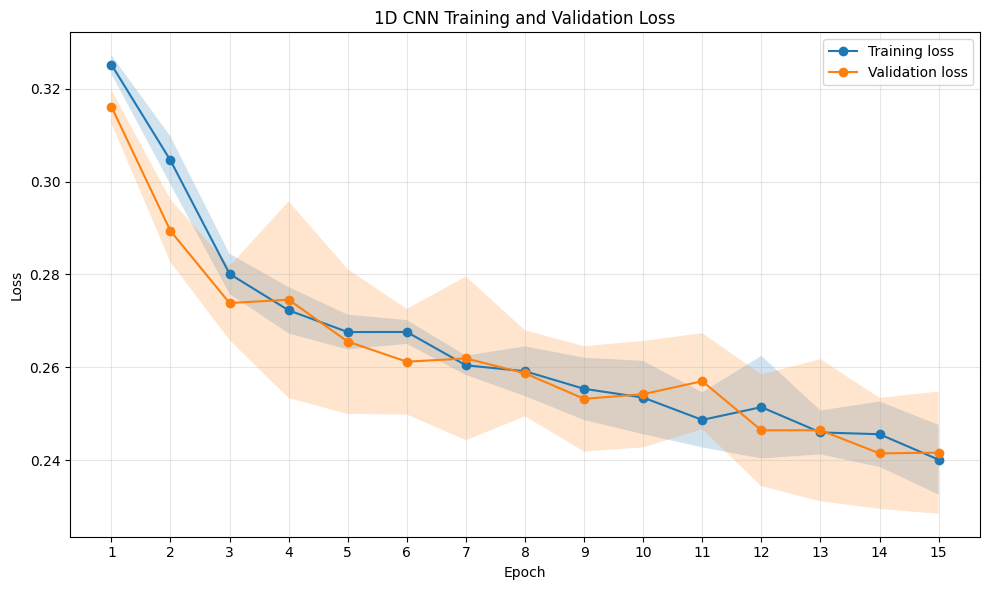

Loss curve saved to:
/content/drive/MyDrive/cinc2025/week7_cnn_loss_curves.png


In [39]:
train_loss_matrix = np.array([
    result["history"]["train_loss"]
    for result in fold_results
])

val_loss_matrix = np.array([
    result["history"]["val_loss"]
    for result in fold_results
])

epoch_numbers = np.arange(1, EPOCHS + 1)

mean_train_loss = train_loss_matrix.mean(axis=0)
std_train_loss = train_loss_matrix.std(axis=0, ddof=1)

mean_val_loss = val_loss_matrix.mean(axis=0)
std_val_loss = val_loss_matrix.std(axis=0, ddof=1)

plt.figure(figsize=(10, 6))

plt.plot(
    epoch_numbers,
    mean_train_loss,
    marker="o",
    label="Training loss"
)

plt.fill_between(
    epoch_numbers,
    mean_train_loss - std_train_loss,
    mean_train_loss + std_train_loss,
    alpha=0.2
)

plt.plot(
    epoch_numbers,
    mean_val_loss,
    marker="o",
    label="Validation loss"
)

plt.fill_between(
    epoch_numbers,
    mean_val_loss - std_val_loss,
    mean_val_loss + std_val_loss,
    alpha=0.2
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("1D CNN Training and Validation Loss")
plt.xticks(epoch_numbers)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

loss_curve_path = (
    project_dir /
    "week7_cnn_loss_curves.png"
)

plt.savefig(
    loss_curve_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Loss curve saved to:")
print(loss_curve_path)

In [40]:
fold_rows = []

for fold_number, result in enumerate(
    fold_results,
    start=1
):
    row = {
        "Fold": fold_number,
        "Best Epoch": result["best_epoch"],
        "Best Validation Loss": result["best_val_loss"]
    }

    row.update(result["metrics"])
    fold_rows.append(row)

cnn_fold_results_df = pd.DataFrame(fold_rows)

print("CNN results for each fold:")
display(cnn_fold_results_df.round(4))

cnn_fold_results_path = (
    project_dir /
    "week7_cnn_fold_results.csv"
)

cnn_fold_results_df.to_csv(
    cnn_fold_results_path,
    index=False
)

print("Fold results saved to:")
print(cnn_fold_results_path)

CNN results for each fold:


,Fold,Best Epoch,Best Validation Loss,Accuracy,Precision,Sensitivity,Specificity,F1,AUROC,Challenge Score
0,1,15,0.2258,0.7048,0.9577,0.6395,0.9109,0.7669,0.8596,0.0658
1,2,14,0.2343,0.7714,0.9185,0.7702,0.7755,0.8378,0.8376,0.0652
2,3,15,0.2447,0.7357,0.9035,0.7312,0.7500,0.8083,0.8193,0.0656
3,4,15,0.2369,0.7476,0.9173,0.7327,0.7941,0.8147,0.8352,0.0660
4,5,14,0.2602,0.6643,0.9091,0.6231,0.7980,0.7394,0.7745,0.0654


Fold results saved to:
/content/drive/MyDrive/cinc2025/week7_cnn_fold_results.csv


In [41]:
metric_columns = [
    "Accuracy",
    "Precision",
    "Sensitivity",
    "Specificity",
    "F1",
    "AUROC",
    "Challenge Score"
]

cnn_means = cnn_fold_results_df[
    metric_columns
].mean()

cnn_stds = cnn_fold_results_df[
    metric_columns
].std(ddof=1)

cnn_summary_df = pd.DataFrame({
    "Metric": metric_columns,
    "Mean": [
        cnn_means[metric]
        for metric in metric_columns
    ],
    "Standard Deviation": [
        cnn_stds[metric]
        for metric in metric_columns
    ],
    "Mean ± SD": [
        (
            f"{cnn_means[metric]:.4f} "
            f"± {cnn_stds[metric]:.4f}"
        )
        for metric in metric_columns
    ]
})

print("CNN five-fold summary:")
display(cnn_summary_df)

cnn_summary_path = (
    project_dir /
    "week7_cnn_summary.csv"
)

cnn_summary_df.to_csv(
    cnn_summary_path,
    index=False
)

print("CNN summary saved to:")
print(cnn_summary_path)

CNN five-fold summary:


,Metric,Mean,Standard Deviation,Mean ± SD
0,Accuracy,0.724762,0.041466,0.7248 ± 0.0415
1,Precision,0.921231,0.021323,0.9212 ± 0.0213
2,Sensitivity,0.699338,0.064326,0.6993 ± 0.0643
3,Specificity,0.805700,0.061792,0.8057 ± 0.0618
4,F1,0.793420,0.039591,0.7934 ± 0.0396
5,AUROC,0.825229,0.031790,0.8252 ± 0.0318
6,Challenge Score,0.065626,0.000324,0.0656 ± 0.0003


CNN summary saved to:
/content/drive/MyDrive/cinc2025/week7_cnn_summary.csv


In [42]:
cnn_oof_metrics = calculate_metrics(
    oof_targets,
    oof_probabilities
)

print("Overall out-of-fold CNN metrics:")

for metric, value in cnn_oof_metrics.items():
    print(f"{metric}: {value:.4f}")

cnn_oof_results_df = feature_df[
    [
        "record_id",
        "patient_id",
        "dataset",
        "label"
    ]
].copy()

cnn_oof_results_df["cnn_probability"] = (
    oof_probabilities
)

cnn_oof_results_df["cnn_prediction"] = (
    oof_probabilities >= 0.5
).astype(int)

cnn_oof_path = (
    project_dir /
    "week7_cnn_oof_predictions.csv"
)

cnn_oof_results_df.to_csv(
    cnn_oof_path,
    index=False
)

print("\nOut-of-fold predictions saved to:")
print(cnn_oof_path)

Overall out-of-fold CNN metrics:
Accuracy: 0.7248
Precision: 0.9202
Sensitivity: 0.6994
Specificity: 0.8060
F1: 0.7947
AUROC: 0.8230
Challenge Score: 0.0656

Out-of-fold predictions saved to:
/content/drive/MyDrive/cinc2025/week7_cnn_oof_predictions.csv


In [43]:
comparison_rows = [
    {
        "Model": "Logistic Regression",
        "Accuracy": "0.7757 ± 0.0270",
        "Precision": "0.9375 ± 0.0071",
        "Sensitivity": "0.7562 ± 0.0424",
        "Specificity": "0.8379 ± 0.0269",
        "F1": "0.8365 ± 0.0243",
        "AUROC": "0.8679 ± 0.0173",
        "Challenge Score": "0.0644 ± 0.0028"
    },
    {
        "Model": "Random Forest",
        "Accuracy": "0.8633 ± 0.0122",
        "Precision": "0.8828 ± 0.0075",
        "Sensitivity": "0.9462 ± 0.0153",
        "Specificity": "0.5980 ± 0.0287",
        "F1": "0.9134 ± 0.0083",
        "AUROC": "0.9134 ± 0.0107",
        "Challenge Score": "0.0656 ± 0.0001"
    },
    {
        "Model": "XGBoost",
        "Accuracy": "0.8724 ± 0.0116",
        "Precision": "0.8974 ± 0.0068",
        "Sensitivity": "0.9400 ± 0.0142",
        "Specificity": "0.6560 ± 0.0243",
        "F1": "0.9181 ± 0.0081",
        "AUROC": "0.9210 ± 0.0071",
        "Challenge Score": "0.0656 ± 0.0001"
    },
    {
        "Model": "XGBoost (Tuned)",
        "Accuracy": "0.8843 ± 0.0084",
        "Precision": "0.9100 ± 0.0035",
        "Sensitivity": "0.9412 ± 0.0161",
        "Specificity": "0.7019 ± 0.0196",
        "F1": "0.9253 ± 0.0063",
        "AUROC": "0.9306 ± 0.0064",
        "Challenge Score": "0.0656 ± 0.0001"
    }
]

cnn_row = {"Model": "1D CNN (Lead II)"}

for metric in metric_columns:
    cnn_row[metric] = (
        f"{cnn_means[metric]:.4f} "
        f"± {cnn_stds[metric]:.4f}"
    )

comparison_rows.append(cnn_row)

comparison_df = pd.DataFrame(comparison_rows)

print("Classical models vs CNN:")
display(comparison_df)

comparison_path = (
    project_dir /
    "week7_model_comparison.csv"
)

comparison_df.to_csv(
    comparison_path,
    index=False
)

print("Comparison table saved to:")
print(comparison_path)

Classical models vs CNN:


,Model,Accuracy,Precision,Sensitivity,Specificity,F1,AUROC,Challenge Score
0,Logistic Regression,0.7757 ± 0.0270,0.9375 ± 0.0071,0.7562 ± 0.0424,0.8379 ± 0.0269,0.8365 ± 0.0243,0.8679 ± 0.0173,0.0644 ± 0.0028
1,Random Forest,0.8633 ± 0.0122,0.8828 ± 0.0075,0.9462 ± 0.0153,0.5980 ± 0.0287,0.9134 ± 0.0083,0.9134 ± 0.0107,0.0656 ± 0.0001
2,XGBoost,0.8724 ± 0.0116,0.8974 ± 0.0068,0.9400 ± 0.0142,0.6560 ± 0.0243,0.9181 ± 0.0081,0.9210 ± 0.0071,0.0656 ± 0.0001
3,XGBoost (Tuned),0.8843 ± 0.0084,0.9100 ± 0.0035,0.9412 ± 0.0161,0.7019 ± 0.0196,0.9253 ± 0.0063,0.9306 ± 0.0064,0.0656 ± 0.0001
4,1D CNN (Lead II),0.7248 ± 0.0415,0.9212 ± 0.0213,0.6993 ± 0.0643,0.8057 ± 0.0618,0.7934 ± 0.0396,0.8252 ± 0.0318,0.0656 ± 0.0003


Comparison table saved to:
/content/drive/MyDrive/cinc2025/week7_model_comparison.csv


In [45]:
tuned_xgboost_means = {
    "Accuracy": 0.8843,
    "Precision": 0.9100,
    "Sensitivity": 0.9412,
    "Specificity": 0.7019,
    "F1": 0.9253,
    "AUROC": 0.9306,
    "Challenge Score": 0.0656
}

comparison_details = []

for metric in metric_columns:
    cnn_value = cnn_means[metric]
    xgboost_value = tuned_xgboost_means[metric]
    difference = cnn_value - xgboost_value

    rounded_difference = round(difference, 4)

    if rounded_difference > 0:
        higher_model = "CNN"
    elif rounded_difference < 0:
        higher_model = "Tuned XGBoost"
    else:
        higher_model = "Tie"

    comparison_details.append({
        "Metric": metric,
        "CNN": cnn_value,
        "Tuned XGBoost": xgboost_value,
        "Difference": difference,
        "Higher Model": higher_model
    })

cnn_vs_xgboost_df = pd.DataFrame(
    comparison_details
)

display(cnn_vs_xgboost_df.round(4))

print(
    "\nThe Lead II CNN did not outperform "
    "tuned XGBoost in mean AUROC."
)

,Metric,CNN,Tuned XGBoost,Difference,Higher Model
0,Accuracy,0.7248,0.8843,-0.1595,Tuned XGBoost
1,Precision,0.9212,0.9100,0.0112,CNN
2,Sensitivity,0.6993,0.9412,-0.2419,Tuned XGBoost
3,Specificity,0.8057,0.7019,0.1038,CNN
4,F1,0.7934,0.9253,-0.1319,Tuned XGBoost
5,AUROC,0.8252,0.9306,-0.1054,Tuned XGBoost
6,Challenge Score,0.0656,0.0656,0.0000,Tie



The Lead II CNN did not outperform tuned XGBoost in mean AUROC.


In [46]:
print("Final comparison:")

print(
    f"The Lead II CNN achieved a mean AUROC of "
    f"{cnn_means['AUROC']:.4f} ± "
    f"{cnn_stds['AUROC']:.4f}."
)

print(
    "The tuned XGBoost baseline achieved a mean "
    "AUROC of 0.9306 ± 0.0064."
)

print(
    "Therefore, the single-lead CNN did not "
    "outperform the best classical baseline."
)

print(
    "The CNN had higher precision and specificity, "
    "but considerably lower sensitivity, F1, "
    "accuracy, and AUROC."
)

print(
    "A limitation is that the positive and negative "
    "records came from different datasets, so some "
    "performance may reflect dataset differences "
    "rather than Chagas disease alone."
)

Final comparison:
The Lead II CNN achieved a mean AUROC of 0.8252 ± 0.0318.
The tuned XGBoost baseline achieved a mean AUROC of 0.9306 ± 0.0064.
Therefore, the single-lead CNN did not outperform the best classical baseline.
The CNN had higher precision and specificity, but considerably lower sensitivity, F1, accuracy, and AUROC.
A limitation is that the positive and negative records came from different datasets, so some performance may reflect dataset differences rather than Chagas disease alone.


In [47]:
ALL_LEADS = [
    "I", "II", "III",
    "AVR", "AVL", "AVF",
    "V1", "V2", "V3",
    "V4", "V5", "V6"
]


def load_preprocessed_12_leads(record_path):
    """
    Load all 12 ECG leads, resample to 100 Hz,
    select a centered 7-second segment, and
    normalize each lead separately.
    """
    header = wfdb.rdheader(record_path)

    available_leads = [
        str(name).strip().upper()
        for name in header.sig_name
    ]

    missing_leads = [
        lead
        for lead in ALL_LEADS
        if lead not in available_leads
    ]

    if missing_leads:
        raise ValueError(
            f"Missing leads in {record_path}: "
            f"{missing_leads}"
        )

    channel_indices = [
        available_leads.index(lead)
        for lead in ALL_LEADS
    ]

    signal, fields = wfdb.rdsamp(
        record_path,
        channels=channel_indices
    )

    signal = signal.astype(np.float32)
    original_fs = int(round(float(fields["fs"])))

    # Replace invalid values separately for each lead.
    for lead_index in range(signal.shape[1]):
        lead_signal = signal[:, lead_index]
        finite_mask = np.isfinite(lead_signal)

        if finite_mask.any():
            replacement = np.median(
                lead_signal[finite_mask]
            )
        else:
            replacement = 0.0

        signal[:, lead_index] = np.nan_to_num(
            lead_signal,
            nan=replacement,
            posinf=replacement,
            neginf=replacement
        )

    # Resample all leads together.
    if original_fs != TARGET_FS:
        common_divisor = gcd(
            original_fs,
            TARGET_FS
        )

        up = TARGET_FS // common_divisor
        down = original_fs // common_divisor

        signal = resample_poly(
            signal,
            up,
            down,
            axis=0
        ).astype(np.float32)

    # Center crop.
    if len(signal) > TARGET_LENGTH:
        start = (
            len(signal) - TARGET_LENGTH
        ) // 2

        signal = signal[
            start:start + TARGET_LENGTH
        ]

    # Symmetric padding.
    elif len(signal) < TARGET_LENGTH:
        total_padding = (
            TARGET_LENGTH - len(signal)
        )

        left_padding = total_padding // 2
        right_padding = (
            total_padding - left_padding
        )

        signal = np.pad(
            signal,
            (
                (left_padding, right_padding),
                (0, 0)
            ),
            mode="constant"
        )

    # Normalize each lead independently.
    lead_means = signal.mean(
        axis=0,
        keepdims=True
    )

    lead_stds = signal.std(
        axis=0,
        keepdims=True
    )

    signal = (
        (signal - lead_means) /
        (lead_stds + 1e-8)
    ).astype(np.float32)

    # PyTorch format: channels × samples
    return signal.T

In [49]:
subset_root = Path("/content/ecg_subset")


def make_record_path(row):
    if row["dataset"] == "SaMi-Trop":
        folder = subset_root / "samitrop"
    else:
        folder = subset_root / "ptbxl"

    return str(folder / str(row["record_id"]))


feature_df["record_path"] = feature_df.apply(
    make_record_path,
    axis=1
)

files_available = feature_df["record_path"].apply(
    lambda path: (
        Path(path + ".hea").exists()
        and Path(path + ".dat").exists()
    )
)

print("Records with both raw files:", files_available.sum())
print("Records missing raw files:", (~files_available).sum())

if not files_available.all():
    raise FileNotFoundError(
        "Some extracted ECG files are missing. "
        "Rerun the selective extraction cell."
    )

Records with both raw files: 2100
Records missing raw files: 0


In [50]:
processed_12lead_examples = {}

for dataset_name in ["SaMi-Trop", "PTB-XL"]:

    sample_row = feature_df.loc[
        feature_df["dataset"] == dataset_name
    ].iloc[0]

    processed_signal = (
        load_preprocessed_12_leads(
            sample_row["record_path"]
        )
    )

    processed_12lead_examples[
        dataset_name
    ] = processed_signal

    print("\nDataset:", dataset_name)
    print("Record ID:", sample_row["record_id"])
    print("Processed shape:", processed_signal.shape)

    print(
        "Average lead mean:",
        round(
            float(
                processed_signal.mean(axis=1).mean()
            ),
            4
        )
    )

    print(
        "Average lead standard deviation:",
        round(
            float(
                processed_signal.std(axis=1).mean()
            ),
            4
        )
    )

    print(
        "Contains invalid values:",
        not np.isfinite(
            processed_signal
        ).all()
    )


Dataset: SaMi-Trop
Record ID: 100726
Processed shape: (12, 700)
Average lead mean: -0.0
Average lead standard deviation: 1.0
Contains invalid values: False

Dataset: PTB-XL
Record ID: 16972_lr
Processed shape: (12, 700)
Average lead mean: -0.0
Average lead standard deviation: 1.0
Contains invalid values: False


In [51]:
cache_12lead_path = (
    project_dir /
    "week7_all12_100hz_7s.npy"
)

expected_12lead_shape = (
    len(feature_df),
    12,
    TARGET_LENGTH
)

rebuild_12lead_cache = True

if cache_12lead_path.exists():
    cached_12lead_signals = np.load(
        cache_12lead_path
    )

    if (
        cached_12lead_signals.shape
        == expected_12lead_shape
    ):
        all_12lead_signals = (
            cached_12lead_signals.astype(
                np.float32,
                copy=False
            )
        )

        rebuild_12lead_cache = False
        print("Loaded existing 12-lead cache.")

    else:
        print(
            "Existing cache has the wrong shape:",
            cached_12lead_signals.shape
        )

if rebuild_12lead_cache:
    all_12lead_signals = np.empty(
        expected_12lead_shape,
        dtype=np.float32
    )

    for index, row in tqdm(
        feature_df.iterrows(),
        total=len(feature_df),
        desc="Preprocessing 12-lead ECGs"
    ):
        all_12lead_signals[index] = (
            load_preprocessed_12_leads(
                row["record_path"]
            )
        )

    np.save(
        cache_12lead_path,
        all_12lead_signals
    )

    print("Created and saved 12-lead cache.")

print(
    "12-lead signal array shape:",
    all_12lead_signals.shape
)

print(
    "Approximate memory:",
    f"{all_12lead_signals.nbytes / (1024 ** 2):.2f} MB"
)

print(
    "All signals finite:",
    np.isfinite(
        all_12lead_signals
    ).all()
)

Preprocessing 12-lead ECGs:   0%|          | 0/2100 [00:00<?, ?it/s]

Created and saved 12-lead cache.
12-lead signal array shape: (2100, 12, 700)
Approximate memory: 67.29 MB
All signals finite: True


In [52]:
class ECG12LeadCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv1d(
                in_channels=12,
                out_channels=16,
                kernel_size=7,
                padding=3
            ),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),

            nn.Conv1d(
                in_channels=16,
                out_channels=32,
                kernel_size=5,
                padding=2
            ),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),

            nn.Conv1d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),

            nn.AdaptiveAvgPool1d(1)
        )

        self.output_layer = nn.Linear(
            in_features=64,
            out_features=1
        )

    def forward(self, x):
        x = self.features(x)
        x = x.flatten(start_dim=1)
        x = self.output_layer(x)

        return x.squeeze(1)


test_12lead_model = ECG12LeadCNN().to(device)

test_12lead_batch = torch.zeros(
    64,
    12,
    TARGET_LENGTH,
    dtype=torch.float32,
    device=device
)

with torch.no_grad():
    test_12lead_output = test_12lead_model(
        test_12lead_batch
    )

parameter_count_12lead = sum(
    parameter.numel()
    for parameter
    in test_12lead_model.parameters()
    if parameter.requires_grad
)

print(test_12lead_model)

print(
    "\nModel output shape:",
    test_12lead_output.shape
)

print(
    "Trainable parameters:",
    parameter_count_12lead
)

ECG12LeadCNN(
  (features): Sequential(
    (0): Conv1d(12, 16, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): ReLU()
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv1d(16, 32, kernel_size=(5,), stride=(1,), padding=(2,))
    (4): ReLU()
    (5): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (7): ReLU()
    (8): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): AdaptiveAvgPool1d(output_size=1)
  )
  (output_layer): Linear(in_features=64, out_features=1, bias=True)
)

Model output shape: torch.Size([64])
Trainable parameters: 10225


In [53]:
def create_signal_loaders(
    signals,
    train_indices,
    val_indices,
    batch_size=BATCH_SIZE,
    fold_seed=SEED
):
    train_dataset = CachedECGDataset(
        signals,
        all_labels,
        train_indices
    )

    val_dataset = CachedECGDataset(
        signals,
        all_labels,
        val_indices
    )

    generator = torch.Generator()
    generator.manual_seed(fold_seed)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
        generator=generator
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available()
    )

    return train_loader, val_loader


def train_signal_fold(
    signals,
    model_class,
    train_indices,
    val_indices,
    fold_number,
    epochs=15,
    learning_rate=0.001
):
    torch.manual_seed(
        SEED + fold_number
    )

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(
            SEED + fold_number
        )

    train_loader, val_loader = (
        create_signal_loaders(
            signals,
            train_indices,
            val_indices,
            fold_seed=SEED + fold_number
        )
    )

    model = model_class().to(device)

    train_fold_labels = all_labels[
        train_indices
    ]

    positive_count = float(
        np.sum(train_fold_labels == 1)
    )

    negative_count = float(
        np.sum(train_fold_labels == 0)
    )

    positive_weight = (
        negative_count / positive_count
    )

    criterion = nn.BCEWithLogitsLoss(
        pos_weight=torch.tensor(
            [positive_weight],
            dtype=torch.float32,
            device=device
        )
    )

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate
    )

    history = {
        "train_loss": [],
        "val_loss": []
    }

    best_val_loss = float("inf")
    best_epoch = 0
    best_state = None

    for epoch in range(1, epochs + 1):
        model.train()
        total_train_loss = 0.0

        for signals_batch, targets in train_loader:
            signals_batch = signals_batch.to(
                device,
                non_blocking=True
            )

            targets = targets.to(
                device,
                non_blocking=True
            )

            optimizer.zero_grad()

            logits = model(signals_batch)
            loss = criterion(logits, targets)

            loss.backward()
            optimizer.step()

            total_train_loss += (
                loss.item() * len(targets)
            )

        train_loss = (
            total_train_loss /
            len(train_loader.dataset)
        )

        val_loss, _, _ = evaluate_model(
            model,
            val_loader,
            criterion
        )

        history["train_loss"].append(
            train_loss
        )

        history["val_loss"].append(
            val_loss
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch

            best_state = {
                name: parameter.detach()
                .cpu()
                .clone()
                for name, parameter
                in model.state_dict().items()
            }

        print(
            f"Fold {fold_number} | "
            f"Epoch {epoch:02d}/{epochs} | "
            f"Train loss: {train_loss:.4f} | "
            f"Validation loss: {val_loss:.4f}"
        )

    model.load_state_dict(best_state)

    final_val_loss, y_true, probabilities = (
        evaluate_model(
            model,
            val_loader,
            criterion
        )
    )

    metrics = calculate_metrics(
        y_true,
        probabilities
    )

    return {
        "model": model,
        "history": history,
        "metrics": metrics,
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "y_true": y_true,
        "probabilities": probabilities
    }

In [54]:
first_train_indices, first_val_indices = (
    fold_splits[0]
)

smoke_test_12lead = train_signal_fold(
    signals=all_12lead_signals,
    model_class=ECG12LeadCNN,
    train_indices=first_train_indices,
    val_indices=first_val_indices,
    fold_number=1,
    epochs=1
)

print(
    "\nBest epoch:",
    smoke_test_12lead["best_epoch"]
)

print("\n12-lead smoke-test metrics:")

for metric, value in (
    smoke_test_12lead["metrics"].items()
):
    print(f"{metric}: {value:.4f}")

Fold 1 | Epoch 01/1 | Train loss: 0.3278 | Validation loss: 0.3202

Best epoch: 1

12-lead smoke-test metrics:
Accuracy: 0.6452
Precision: 0.9521
Sensitivity: 0.5611
Specificity: 0.9109
F1: 0.7061
AUROC: 0.8303
Challenge Score: 0.0658


In [55]:
import pickle

OPTIONAL_EPOCHS = 15
OPTIONAL_LEARNING_RATE = 0.001

twelve_lead_fold_results = []

twelve_lead_oof_probabilities = np.full(
    len(feature_df),
    np.nan,
    dtype=np.float32
)

for fold_number, (
    train_indices,
    val_indices
) in enumerate(fold_splits, start=1):

    print(f"\nTraining 12-lead fold {fold_number}/5")

    result = train_signal_fold(
        signals=all_12lead_signals,
        model_class=ECG12LeadCNN,
        train_indices=train_indices,
        val_indices=val_indices,
        fold_number=fold_number,
        epochs=OPTIONAL_EPOCHS,
        learning_rate=OPTIONAL_LEARNING_RATE
    )

    twelve_lead_oof_probabilities[
        val_indices
    ] = result["probabilities"]

    print(
        f"\nFold {fold_number} best epoch:",
        result["best_epoch"]
    )

    print(
        f"Fold {fold_number} best validation loss:",
        f"{result['best_val_loss']:.4f}"
    )

    print(f"\nFold {fold_number} metrics:")

    for metric, value in result["metrics"].items():
        print(f"{metric}: {value:.4f}")

    trained_model = result.pop("model")
    del trained_model

    twelve_lead_fold_results.append(result)

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

assert np.isfinite(
    twelve_lead_oof_probabilities
).all(), "Some 12-lead predictions are missing."

twelve_lead_saved_results = {
    "fold_results": twelve_lead_fold_results,
    "oof_probabilities": (
        twelve_lead_oof_probabilities
    ),
    "oof_targets": oof_targets,
    "epochs": OPTIONAL_EPOCHS
}

twelve_lead_results_path = (
    project_dir /
    "week7_12lead_cnn_training_results.pkl"
)

with open(
    twelve_lead_results_path,
    "wb"
) as file:
    pickle.dump(
        twelve_lead_saved_results,
        file
    )

print("\nFive-fold 12-lead CNN training complete.")

print("\nTraining results saved to:")
print(twelve_lead_results_path)


Training 12-lead fold 1/5
Fold 1 | Epoch 01/15 | Train loss: 0.3278 | Validation loss: 0.3202
Fold 1 | Epoch 02/15 | Train loss: 0.2993 | Validation loss: 0.2648
Fold 1 | Epoch 03/15 | Train loss: 0.2522 | Validation loss: 0.2444
Fold 1 | Epoch 04/15 | Train loss: 0.2426 | Validation loss: 0.2280
Fold 1 | Epoch 05/15 | Train loss: 0.2313 | Validation loss: 0.2239
Fold 1 | Epoch 06/15 | Train loss: 0.2242 | Validation loss: 0.2205
Fold 1 | Epoch 07/15 | Train loss: 0.2140 | Validation loss: 0.2141
Fold 1 | Epoch 08/15 | Train loss: 0.2075 | Validation loss: 0.2144
Fold 1 | Epoch 09/15 | Train loss: 0.2012 | Validation loss: 0.2104
Fold 1 | Epoch 10/15 | Train loss: 0.2012 | Validation loss: 0.2041
Fold 1 | Epoch 11/15 | Train loss: 0.1862 | Validation loss: 0.2823
Fold 1 | Epoch 12/15 | Train loss: 0.2183 | Validation loss: 0.2196
Fold 1 | Epoch 13/15 | Train loss: 0.1927 | Validation loss: 0.2010
Fold 1 | Epoch 14/15 | Train loss: 0.1792 | Validation loss: 0.1933
Fold 1 | Epoch 15/15 

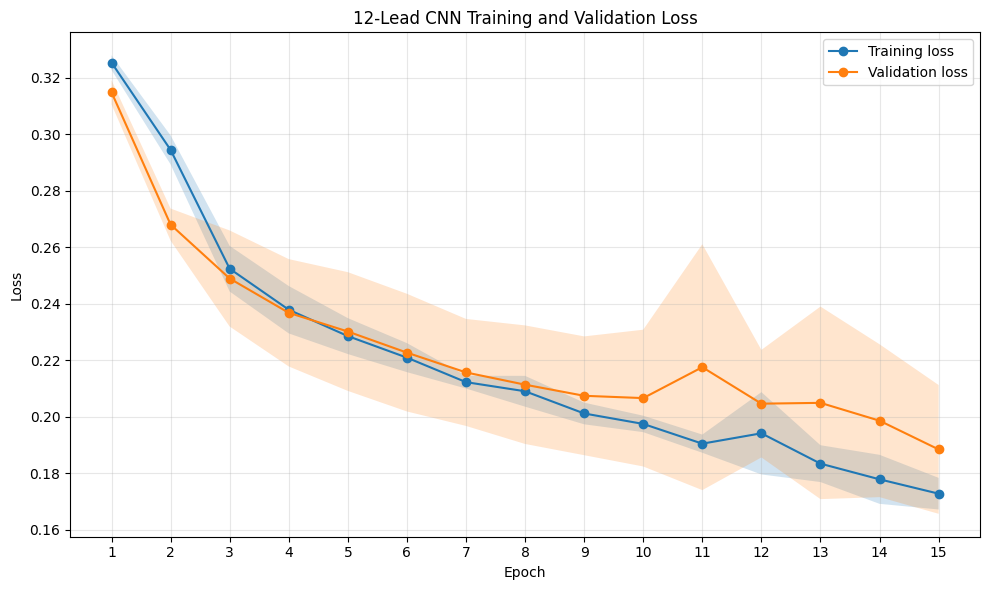

12-lead loss curve saved to:
/content/drive/MyDrive/cinc2025/week7_12lead_cnn_loss_curves.png


In [56]:
twelve_train_loss_matrix = np.array([
    result["history"]["train_loss"]
    for result in twelve_lead_fold_results
])

twelve_val_loss_matrix = np.array([
    result["history"]["val_loss"]
    for result in twelve_lead_fold_results
])

optional_epoch_numbers = np.arange(
    1,
    OPTIONAL_EPOCHS + 1
)

twelve_mean_train_loss = (
    twelve_train_loss_matrix.mean(axis=0)
)

twelve_std_train_loss = (
    twelve_train_loss_matrix.std(
        axis=0,
        ddof=1
    )
)

twelve_mean_val_loss = (
    twelve_val_loss_matrix.mean(axis=0)
)

twelve_std_val_loss = (
    twelve_val_loss_matrix.std(
        axis=0,
        ddof=1
    )
)

plt.figure(figsize=(10, 6))

plt.plot(
    optional_epoch_numbers,
    twelve_mean_train_loss,
    marker="o",
    label="Training loss"
)

plt.fill_between(
    optional_epoch_numbers,
    twelve_mean_train_loss -
    twelve_std_train_loss,
    twelve_mean_train_loss +
    twelve_std_train_loss,
    alpha=0.2
)

plt.plot(
    optional_epoch_numbers,
    twelve_mean_val_loss,
    marker="o",
    label="Validation loss"
)

plt.fill_between(
    optional_epoch_numbers,
    twelve_mean_val_loss -
    twelve_std_val_loss,
    twelve_mean_val_loss +
    twelve_std_val_loss,
    alpha=0.2
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(
    "12-Lead CNN Training and Validation Loss"
)
plt.xticks(optional_epoch_numbers)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

twelve_loss_curve_path = (
    project_dir /
    "week7_12lead_cnn_loss_curves.png"
)

plt.savefig(
    twelve_loss_curve_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("12-lead loss curve saved to:")
print(twelve_loss_curve_path)

In [57]:
twelve_lead_fold_rows = []

for fold_number, result in enumerate(
    twelve_lead_fold_results,
    start=1
):
    row = {
        "Fold": fold_number,
        "Best Epoch": result["best_epoch"],
        "Best Validation Loss": (
            result["best_val_loss"]
        )
    }

    row.update(result["metrics"])
    twelve_lead_fold_rows.append(row)

twelve_lead_fold_results_df = pd.DataFrame(
    twelve_lead_fold_rows
)

print("12-lead CNN results for each fold:")
display(
    twelve_lead_fold_results_df.round(4)
)

twelve_lead_means = (
    twelve_lead_fold_results_df[
        metric_columns
    ].mean()
)

twelve_lead_stds = (
    twelve_lead_fold_results_df[
        metric_columns
    ].std(ddof=1)
)

twelve_lead_summary_df = pd.DataFrame({
    "Metric": metric_columns,
    "Mean": [
        twelve_lead_means[metric]
        for metric in metric_columns
    ],
    "Standard Deviation": [
        twelve_lead_stds[metric]
        for metric in metric_columns
    ],
    "Mean ± SD": [
        (
            f"{twelve_lead_means[metric]:.4f} "
            f"± {twelve_lead_stds[metric]:.4f}"
        )
        for metric in metric_columns
    ]
})

print("\n12-lead CNN five-fold summary:")
display(twelve_lead_summary_df)

twelve_lead_oof_metrics = calculate_metrics(
    oof_targets,
    twelve_lead_oof_probabilities
)

print("\nOverall out-of-fold 12-lead metrics:")

for metric, value in (
    twelve_lead_oof_metrics.items()
):
    print(f"{metric}: {value:.4f}")

twelve_lead_fold_path = (
    project_dir /
    "week7_12lead_cnn_fold_results.csv"
)

twelve_lead_summary_path = (
    project_dir /
    "week7_12lead_cnn_summary.csv"
)

twelve_lead_fold_results_df.to_csv(
    twelve_lead_fold_path,
    index=False
)

twelve_lead_summary_df.to_csv(
    twelve_lead_summary_path,
    index=False
)

print("\n12-lead results saved.")

12-lead CNN results for each fold:


,Fold,Best Epoch,Best Validation Loss,Accuracy,Precision,Sensitivity,Specificity,F1,AUROC,Challenge Score
0,1,15,0.1902,0.7929,0.9531,0.7649,0.8812,0.8487,0.9026,0.0658
1,2,15,0.1771,0.7952,0.9436,0.7795,0.8469,0.8537,0.9098,0.0652
2,3,13,0.1680,0.8476,0.9604,0.8344,0.8900,0.8930,0.9230,0.0656
3,4,15,0.1722,0.8214,0.9551,0.8019,0.8824,0.8718,0.9192,0.0660
4,5,15,0.2273,0.8048,0.9193,0.8162,0.7677,0.8647,0.8660,0.0654



12-lead CNN five-fold summary:


,Metric,Mean,Standard Deviation,Mean ± SD
0,Accuracy,0.812381,0.022675,0.8124 ± 0.0227
1,Precision,0.946304,0.016273,0.9463 ± 0.0163
2,Sensitivity,0.799371,0.027832,0.7994 ± 0.0278
3,Specificity,0.853631,0.050843,0.8536 ± 0.0508
4,F1,0.866379,0.017407,0.8664 ± 0.0174
5,AUROC,0.904106,0.022765,0.9041 ± 0.0228
6,Challenge Score,0.065626,0.000324,0.0656 ± 0.0003



Overall out-of-fold 12-lead metrics:
Accuracy: 0.8124
Precision: 0.9460
Sensitivity: 0.7994
Specificity: 0.8540
F1: 0.8665
AUROC: 0.9034
Challenge Score: 0.0650

12-lead results saved.


In [58]:
lead_comparison_rows = []

for model_name, means, stds in [
    (
        "1D CNN (Lead II)",
        cnn_means,
        cnn_stds
    ),
    (
        "1D CNN (12 Leads)",
        twelve_lead_means,
        twelve_lead_stds
    )
]:
    row = {
        "Model": model_name
    }

    for metric in metric_columns:
        row[metric] = (
            f"{means[metric]:.4f} "
            f"± {stds[metric]:.4f}"
        )

    lead_comparison_rows.append(row)

lead_comparison_df = pd.DataFrame(
    lead_comparison_rows
)

print("Lead II vs 12-lead CNN:")
display(lead_comparison_df)

auroc_difference = (
    twelve_lead_means["AUROC"] -
    cnn_means["AUROC"]
)

print(
    "\nMean AUROC difference "
    "(12 leads minus Lead II): "
    f"{auroc_difference:.4f}"
)

if auroc_difference > 0:
    print(
        "Using all 12 leads improved mean AUROC."
    )
elif auroc_difference < 0:
    print(
        "Using all 12 leads reduced mean AUROC."
    )
else:
    print(
        "Using all 12 leads produced the same "
        "mean AUROC."
    )

Lead II vs 12-lead CNN:


,Model,Accuracy,Precision,Sensitivity,Specificity,F1,AUROC,Challenge Score
0,1D CNN (Lead II),0.7248 ± 0.0415,0.9212 ± 0.0213,0.6993 ± 0.0643,0.8057 ± 0.0618,0.7934 ± 0.0396,0.8252 ± 0.0318,0.0656 ± 0.0003
1,1D CNN (12 Leads),0.8124 ± 0.0227,0.9463 ± 0.0163,0.7994 ± 0.0278,0.8536 ± 0.0508,0.8664 ± 0.0174,0.9041 ± 0.0228,0.0656 ± 0.0003



Mean AUROC difference (12 leads minus Lead II): 0.0789
Using all 12 leads improved mean AUROC.


In [59]:
class ECG12LeadRegularizedCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv1d(
                in_channels=12,
                out_channels=16,
                kernel_size=7,
                padding=3
            ),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Dropout(p=0.15),

            nn.Conv1d(
                in_channels=16,
                out_channels=32,
                kernel_size=5,
                padding=2
            ),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Dropout(p=0.20),

            nn.Conv1d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Dropout(p=0.25),

            nn.AdaptiveAvgPool1d(1)
        )

        self.classifier_dropout = nn.Dropout(
            p=0.30
        )

        self.output_layer = nn.Linear(
            in_features=64,
            out_features=1
        )

    def forward(self, x):
        x = self.features(x)
        x = x.flatten(start_dim=1)
        x = self.classifier_dropout(x)
        x = self.output_layer(x)

        return x.squeeze(1)


test_regularized_model = (
    ECG12LeadRegularizedCNN().to(device)
)

test_regularized_batch = torch.zeros(
    64,
    12,
    TARGET_LENGTH,
    dtype=torch.float32,
    device=device
)

test_regularized_model.eval()

with torch.no_grad():
    test_regularized_output = (
        test_regularized_model(
            test_regularized_batch
        )
    )

regularized_parameter_count = sum(
    parameter.numel()
    for parameter
    in test_regularized_model.parameters()
    if parameter.requires_grad
)

print(test_regularized_model)

print(
    "\nModel output shape:",
    test_regularized_output.shape
)

print(
    "Trainable parameters:",
    regularized_parameter_count
)

ECG12LeadRegularizedCNN(
  (features): Sequential(
    (0): Conv1d(12, 16, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.15, inplace=False)
    (5): Conv1d(16, 32, kernel_size=(5,), stride=(1,), padding=(2,))
    (6): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()
    (8): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Dropout(p=0.2, inplace=False)
    (10): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (11): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Dropout(p=0.25, inplace=False)
    (15): AdaptiveAvgPool1d(output_size=1)
  )
  (c

In [60]:
regularized_smoke_test = train_signal_fold(
    signals=all_12lead_signals,
    model_class=ECG12LeadRegularizedCNN,
    train_indices=first_train_indices,
    val_indices=first_val_indices,
    fold_number=1,
    epochs=1
)

print(
    "\nBest epoch:",
    regularized_smoke_test["best_epoch"]
)

print(
    "\nBatch normalization and dropout "
    "smoke-test metrics:"
)

for metric, value in (
    regularized_smoke_test["metrics"].items()
):
    print(f"{metric}: {value:.4f}")

Fold 1 | Epoch 01/1 | Train loss: 0.3030 | Validation loss: 0.2711

Best epoch: 1

Batch normalization and dropout smoke-test metrics:
Accuracy: 0.6452
Precision: 0.9570
Sensitivity: 0.5580
Specificity: 0.9208
F1: 0.7050
AUROC: 0.8418
Challenge Score: 0.0658


In [61]:
REGULARIZED_EPOCHS = 15
REGULARIZED_LEARNING_RATE = 0.001

regularized_fold_results = []

regularized_oof_probabilities = np.full(
    len(feature_df),
    np.nan,
    dtype=np.float32
)

for fold_number, (
    train_indices,
    val_indices
) in enumerate(fold_splits, start=1):

    print(
        f"\nTraining regularized "
        f"12-lead fold {fold_number}/5"
    )

    result = train_signal_fold(
        signals=all_12lead_signals,
        model_class=ECG12LeadRegularizedCNN,
        train_indices=train_indices,
        val_indices=val_indices,
        fold_number=fold_number,
        epochs=REGULARIZED_EPOCHS,
        learning_rate=REGULARIZED_LEARNING_RATE
    )

    regularized_oof_probabilities[
        val_indices
    ] = result["probabilities"]

    print(
        f"\nFold {fold_number} best epoch:",
        result["best_epoch"]
    )

    print(
        f"Fold {fold_number} best "
        f"validation loss:",
        f"{result['best_val_loss']:.4f}"
    )

    print(f"\nFold {fold_number} metrics:")

    for metric, value in (
        result["metrics"].items()
    ):
        print(f"{metric}: {value:.4f}")

    trained_model = result.pop("model")
    del trained_model

    regularized_fold_results.append(result)

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

assert np.isfinite(
    regularized_oof_probabilities
).all(), (
    "Some regularized-model predictions "
    "are missing."
)

regularized_saved_results = {
    "fold_results": regularized_fold_results,
    "oof_probabilities": (
        regularized_oof_probabilities
    ),
    "oof_targets": oof_targets,
    "epochs": REGULARIZED_EPOCHS
}

regularized_results_path = (
    project_dir /
    "week7_12lead_regularized_results.pkl"
)

with open(
    regularized_results_path,
    "wb"
) as file:
    pickle.dump(
        regularized_saved_results,
        file
    )

print(
    "\nFive-fold regularized CNN "
    "training complete."
)

print("\nTraining results saved to:")
print(regularized_results_path)


Training regularized 12-lead fold 1/5
Fold 1 | Epoch 01/15 | Train loss: 0.3030 | Validation loss: 0.2711
Fold 1 | Epoch 02/15 | Train loss: 0.2546 | Validation loss: 0.2283
Fold 1 | Epoch 03/15 | Train loss: 0.2326 | Validation loss: 0.2140
Fold 1 | Epoch 04/15 | Train loss: 0.2140 | Validation loss: 0.2042
Fold 1 | Epoch 05/15 | Train loss: 0.2001 | Validation loss: 0.1982
Fold 1 | Epoch 06/15 | Train loss: 0.1940 | Validation loss: 0.1945
Fold 1 | Epoch 07/15 | Train loss: 0.1777 | Validation loss: 0.1862
Fold 1 | Epoch 08/15 | Train loss: 0.1668 | Validation loss: 0.1812
Fold 1 | Epoch 09/15 | Train loss: 0.1628 | Validation loss: 0.1772
Fold 1 | Epoch 10/15 | Train loss: 0.1573 | Validation loss: 0.1863
Fold 1 | Epoch 11/15 | Train loss: 0.1526 | Validation loss: 0.1680
Fold 1 | Epoch 12/15 | Train loss: 0.1385 | Validation loss: 0.1672
Fold 1 | Epoch 13/15 | Train loss: 0.1361 | Validation loss: 0.1851
Fold 1 | Epoch 14/15 | Train loss: 0.1407 | Validation loss: 0.1710
Fold 1 | 

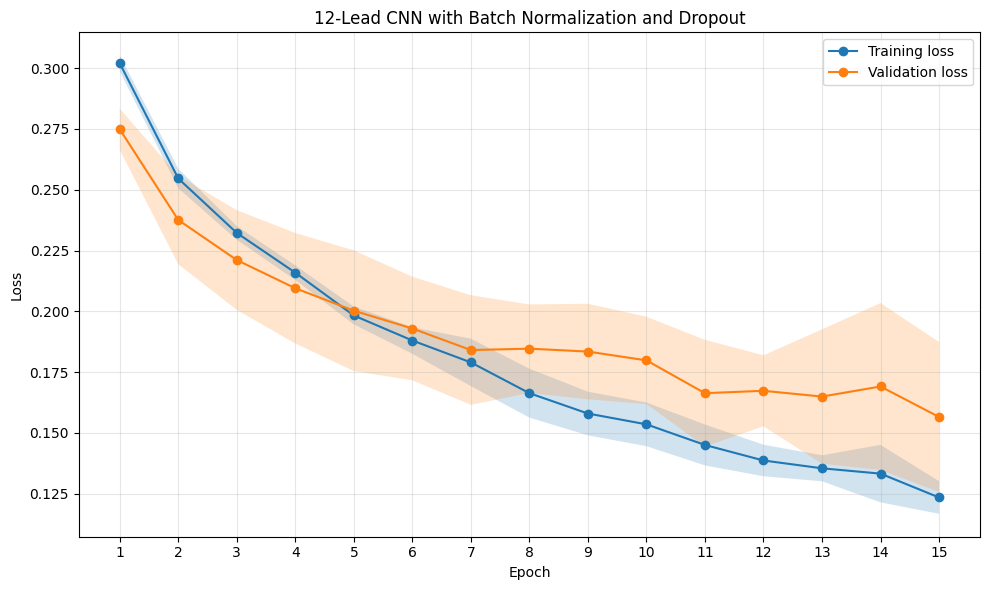

Regularized loss curve saved to:
/content/drive/MyDrive/cinc2025/week7_12lead_regularized_loss.png


In [62]:
regularized_train_loss_matrix = np.array([
    result["history"]["train_loss"]
    for result in regularized_fold_results
])

regularized_val_loss_matrix = np.array([
    result["history"]["val_loss"]
    for result in regularized_fold_results
])

regularized_epoch_numbers = np.arange(
    1,
    REGULARIZED_EPOCHS + 1
)

regularized_mean_train_loss = (
    regularized_train_loss_matrix.mean(axis=0)
)

regularized_std_train_loss = (
    regularized_train_loss_matrix.std(
        axis=0,
        ddof=1
    )
)

regularized_mean_val_loss = (
    regularized_val_loss_matrix.mean(axis=0)
)

regularized_std_val_loss = (
    regularized_val_loss_matrix.std(
        axis=0,
        ddof=1
    )
)

plt.figure(figsize=(10, 6))

plt.plot(
    regularized_epoch_numbers,
    regularized_mean_train_loss,
    marker="o",
    label="Training loss"
)

plt.fill_between(
    regularized_epoch_numbers,
    regularized_mean_train_loss -
    regularized_std_train_loss,
    regularized_mean_train_loss +
    regularized_std_train_loss,
    alpha=0.2
)

plt.plot(
    regularized_epoch_numbers,
    regularized_mean_val_loss,
    marker="o",
    label="Validation loss"
)

plt.fill_between(
    regularized_epoch_numbers,
    regularized_mean_val_loss -
    regularized_std_val_loss,
    regularized_mean_val_loss +
    regularized_std_val_loss,
    alpha=0.2
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "12-Lead CNN with Batch Normalization "
    "and Dropout"
)

plt.xticks(regularized_epoch_numbers)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

regularized_loss_path = (
    project_dir /
    "week7_12lead_regularized_loss.png"
)

plt.savefig(
    regularized_loss_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Regularized loss curve saved to:")
print(regularized_loss_path)

In [63]:
regularized_fold_rows = []

for fold_number, result in enumerate(
    regularized_fold_results,
    start=1
):
    row = {
        "Fold": fold_number,
        "Best Epoch": result["best_epoch"],
        "Best Validation Loss": (
            result["best_val_loss"]
        )
    }

    row.update(result["metrics"])
    regularized_fold_rows.append(row)

regularized_fold_results_df = pd.DataFrame(
    regularized_fold_rows
)

print(
    "Regularized 12-lead CNN results "
    "for each fold:"
)

display(
    regularized_fold_results_df.round(4)
)

regularized_means = (
    regularized_fold_results_df[
        metric_columns
    ].mean()
)

regularized_stds = (
    regularized_fold_results_df[
        metric_columns
    ].std(ddof=1)
)

regularized_summary_df = pd.DataFrame({
    "Metric": metric_columns,
    "Mean": [
        regularized_means[metric]
        for metric in metric_columns
    ],
    "Standard Deviation": [
        regularized_stds[metric]
        for metric in metric_columns
    ],
    "Mean ± SD": [
        (
            f"{regularized_means[metric]:.4f} "
            f"± {regularized_stds[metric]:.4f}"
        )
        for metric in metric_columns
    ]
})

print(
    "\nRegularized 12-lead CNN "
    "five-fold summary:"
)

display(regularized_summary_df)

regularized_oof_metrics = calculate_metrics(
    oof_targets,
    regularized_oof_probabilities
)

print(
    "\nOverall out-of-fold regularized metrics:"
)

for metric, value in (
    regularized_oof_metrics.items()
):
    print(f"{metric}: {value:.4f}")

regularized_fold_path = (
    project_dir /
    "week7_12lead_regularized_folds.csv"
)

regularized_summary_path = (
    project_dir /
    "week7_12lead_regularized_summary.csv"
)

regularized_fold_results_df.to_csv(
    regularized_fold_path,
    index=False
)

regularized_summary_df.to_csv(
    regularized_summary_path,
    index=False
)

print("\nRegularized results saved.")

Regularized 12-lead CNN results for each fold:


,Fold,Best Epoch,Best Validation Loss,Accuracy,Precision,Sensitivity,Specificity,F1,AUROC,Challenge Score
0,1,12,0.1672,0.8738,0.9375,0.8934,0.8119,0.9149,0.9316,0.0658
1,2,15,0.1362,0.8548,0.9745,0.8323,0.9286,0.8978,0.9546,0.0652
2,3,14,0.1426,0.9048,0.9459,0.9281,0.8300,0.9369,0.9550,0.0656
3,4,15,0.1278,0.9190,0.9522,0.9403,0.8529,0.9462,0.9657,0.0660
4,5,12,0.1877,0.8262,0.9460,0.8193,0.8485,0.8781,0.9037,0.0654



Regularized 12-lead CNN five-fold summary:


,Metric,Mean,Standard Deviation,Mean ± SD
0,Accuracy,0.875714,0.037473,0.8757 ± 0.0375
1,Precision,0.951236,0.014043,0.9512 ± 0.0140
2,Sensitivity,0.882681,0.054883,0.8827 ± 0.0549
3,Specificity,0.854376,0.044558,0.8544 ± 0.0446
4,F1,0.914798,0.027874,0.9148 ± 0.0279
5,AUROC,0.942103,0.024797,0.9421 ± 0.0248
6,Challenge Score,0.065626,0.000324,0.0656 ± 0.0003



Overall out-of-fold regularized metrics:
Accuracy: 0.8757
Precision: 0.9508
Sensitivity: 0.8825
Specificity: 0.8540
F1: 0.9154
AUROC: 0.9401
Challenge Score: 0.0656

Regularized results saved.


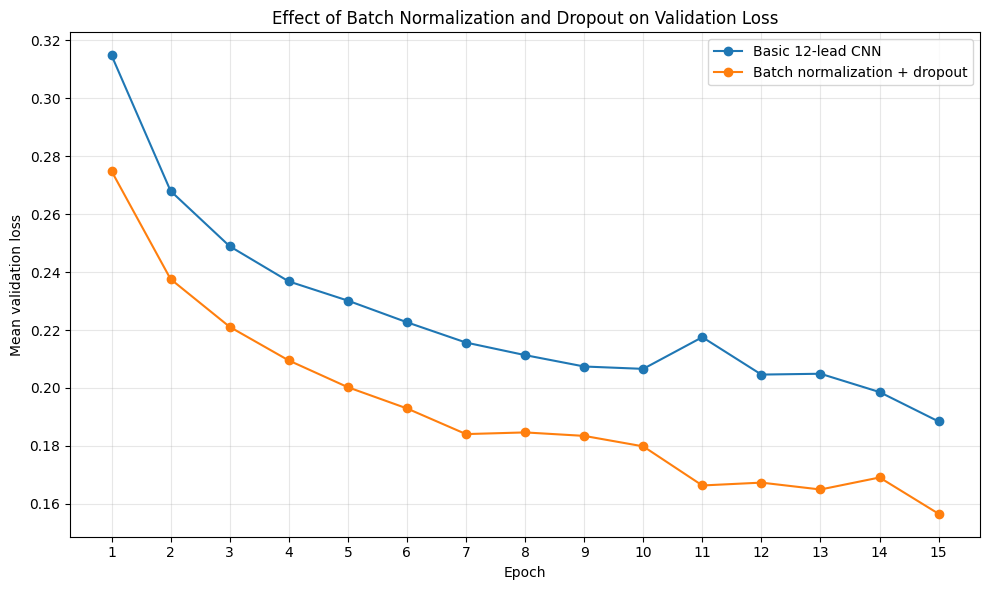

Basic 12-lead minimum mean validation loss: 0.1884
Regularized minimum mean validation loss: 0.1566
Basic 12-lead mean AUROC: 0.9041
Regularized mean AUROC: 0.9421


In [64]:
plt.figure(figsize=(10, 6))

plt.plot(
    optional_epoch_numbers,
    twelve_mean_val_loss,
    marker="o",
    label="Basic 12-lead CNN"
)

plt.plot(
    regularized_epoch_numbers,
    regularized_mean_val_loss,
    marker="o",
    label="Batch normalization + dropout"
)

plt.xlabel("Epoch")
plt.ylabel("Mean validation loss")

plt.title(
    "Effect of Batch Normalization and Dropout "
    "on Validation Loss"
)

plt.xticks(regularized_epoch_numbers)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

regularization_comparison_path = (
    project_dir /
    "week7_regularization_comparison.png"
)

plt.savefig(
    regularization_comparison_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

basic_min_val_loss = (
    twelve_mean_val_loss.min()
)

regularized_min_val_loss = (
    regularized_mean_val_loss.min()
)

print(
    "Basic 12-lead minimum mean "
    "validation loss:",
    f"{basic_min_val_loss:.4f}"
)

print(
    "Regularized minimum mean "
    "validation loss:",
    f"{regularized_min_val_loss:.4f}"
)

print(
    "Basic 12-lead mean AUROC:",
    f"{twelve_lead_means['AUROC']:.4f}"
)

print(
    "Regularized mean AUROC:",
    f"{regularized_means['AUROC']:.4f}"
)

In [65]:
optional_comparison_rows = []

for model_name, means, stds in [
    (
        "1D CNN (Lead II)",
        cnn_means,
        cnn_stds
    ),
    (
        "1D CNN (12 Leads)",
        twelve_lead_means,
        twelve_lead_stds
    ),
    (
        "12 Leads + BatchNorm/Dropout",
        regularized_means,
        regularized_stds
    )
]:
    row = {
        "Model": model_name
    }

    for metric in metric_columns:
        row[metric] = (
            f"{means[metric]:.4f} "
            f"± {stds[metric]:.4f}"
        )

    optional_comparison_rows.append(row)

optional_comparison_df = pd.DataFrame(
    optional_comparison_rows
)

print("CNN experiment comparison:")
display(optional_comparison_df)

regularized_auroc_difference = (
    regularized_means["AUROC"] -
    twelve_lead_means["AUROC"]
)

print(
    "\nMean AUROC difference "
    "(regularized minus basic 12-lead): "
    f"{regularized_auroc_difference:.4f}"
)

if regularized_auroc_difference > 0:
    print(
        "Batch normalization and dropout "
        "improved mean AUROC."
    )
elif regularized_auroc_difference < 0:
    print(
        "Batch normalization and dropout "
        "reduced mean AUROC."
    )
else:
    print(
        "Batch normalization and dropout "
        "did not change mean AUROC."
    )

CNN experiment comparison:


,Model,Accuracy,Precision,Sensitivity,Specificity,F1,AUROC,Challenge Score
0,1D CNN (Lead II),0.7248 ± 0.0415,0.9212 ± 0.0213,0.6993 ± 0.0643,0.8057 ± 0.0618,0.7934 ± 0.0396,0.8252 ± 0.0318,0.0656 ± 0.0003
1,1D CNN (12 Leads),0.8124 ± 0.0227,0.9463 ± 0.0163,0.7994 ± 0.0278,0.8536 ± 0.0508,0.8664 ± 0.0174,0.9041 ± 0.0228,0.0656 ± 0.0003
2,12 Leads + BatchNorm/Dropout,0.8757 ± 0.0375,0.9512 ± 0.0140,0.8827 ± 0.0549,0.8544 ± 0.0446,0.9148 ± 0.0279,0.9421 ± 0.0248,0.0656 ± 0.0003



Mean AUROC difference (regularized minus basic 12-lead): 0.0380
Batch normalization and dropout improved mean AUROC.


In [66]:
final_comparison_rows = [
    {
        "Model": "Tuned XGBoost",
        "Accuracy": "0.8843 ± 0.0084",
        "Precision": "0.9100 ± 0.0035",
        "Sensitivity": "0.9412 ± 0.0161",
        "Specificity": "0.7019 ± 0.0196",
        "F1": "0.9253 ± 0.0063",
        "AUROC": "0.9306 ± 0.0064",
        "Challenge Score": "0.0656 ± 0.0001"
    }
]

for model_name, means, stds in [
    (
        "1D CNN (Lead II)",
        cnn_means,
        cnn_stds
    ),
    (
        "1D CNN (12 Leads)",
        twelve_lead_means,
        twelve_lead_stds
    ),
    (
        "12 Leads + BatchNorm/Dropout",
        regularized_means,
        regularized_stds
    )
]:
    row = {"Model": model_name}

    for metric in metric_columns:
        row[metric] = (
            f"{means[metric]:.4f} "
            f"± {stds[metric]:.4f}"
        )

    final_comparison_rows.append(row)

final_comparison_df = pd.DataFrame(
    final_comparison_rows
)

print("Final model comparison:")
display(final_comparison_df)

final_comparison_path = (
    project_dir /
    "week7_final_model_comparison.csv"
)

final_comparison_df.to_csv(
    final_comparison_path,
    index=False
)

print("Final comparison saved to:")
print(final_comparison_path)

Final model comparison:


,Model,Accuracy,Precision,Sensitivity,Specificity,F1,AUROC,Challenge Score
0,Tuned XGBoost,0.8843 ± 0.0084,0.9100 ± 0.0035,0.9412 ± 0.0161,0.7019 ± 0.0196,0.9253 ± 0.0063,0.9306 ± 0.0064,0.0656 ± 0.0001
1,1D CNN (Lead II),0.7248 ± 0.0415,0.9212 ± 0.0213,0.6993 ± 0.0643,0.8057 ± 0.0618,0.7934 ± 0.0396,0.8252 ± 0.0318,0.0656 ± 0.0003
2,1D CNN (12 Leads),0.8124 ± 0.0227,0.9463 ± 0.0163,0.7994 ± 0.0278,0.8536 ± 0.0508,0.8664 ± 0.0174,0.9041 ± 0.0228,0.0656 ± 0.0003
3,12 Leads + BatchNorm/Dropout,0.8757 ± 0.0375,0.9512 ± 0.0140,0.8827 ± 0.0549,0.8544 ± 0.0446,0.9148 ± 0.0279,0.9421 ± 0.0248,0.0656 ± 0.0003


Final comparison saved to:
/content/drive/MyDrive/cinc2025/week7_final_model_comparison.csv


In [67]:
xgboost_auroc = 0.9306

lead_improvement = (
    twelve_lead_means["AUROC"] -
    cnn_means["AUROC"]
)

regularization_improvement = (
    regularized_means["AUROC"] -
    twelve_lead_means["AUROC"]
)

xgboost_difference = (
    regularized_means["AUROC"] -
    xgboost_auroc
)

print("Final conclusions:")

print(
    f"The Lead II CNN achieved a mean AUROC of "
    f"{cnn_means['AUROC']:.4f} ± "
    f"{cnn_stds['AUROC']:.4f}."
)

print(
    f"Using all 12 leads increased mean AUROC by "
    f"{lead_improvement:.4f}, reaching "
    f"{twelve_lead_means['AUROC']:.4f} ± "
    f"{twelve_lead_stds['AUROC']:.4f}."
)

print(
    f"Adding batch normalization and dropout "
    f"increased mean AUROC by another "
    f"{regularization_improvement:.4f}, reaching "
    f"{regularized_means['AUROC']:.4f} ± "
    f"{regularized_stds['AUROC']:.4f}."
)

print(
    f"The regularized 12-lead CNN had a mean AUROC "
    f"{xgboost_difference:.4f} higher than tuned "
    f"XGBoost."
)

print(
    "Batch normalization and dropout also reduced "
    "the minimum mean validation loss from "
    f"{basic_min_val_loss:.4f} to "
    f"{regularized_min_val_loss:.4f}."
)

print(
    "Therefore, the optional 12-lead regularized CNN "
    "produced the highest mean AUROC in this comparison."
)

print(
    "However, the positive and negative records came "
    "from different datasets, so some performance may "
    "reflect dataset or recording differences rather "
    "than Chagas disease alone."
)

Final conclusions:
The Lead II CNN achieved a mean AUROC of 0.8252 ± 0.0318.
Using all 12 leads increased mean AUROC by 0.0789, reaching 0.9041 ± 0.0228.
Adding batch normalization and dropout increased mean AUROC by another 0.0380, reaching 0.9421 ± 0.0248.
The regularized 12-lead CNN had a mean AUROC 0.0115 higher than tuned XGBoost.
Batch normalization and dropout also reduced the minimum mean validation loss from 0.1884 to 0.1566.
Therefore, the optional 12-lead regularized CNN produced the highest mean AUROC in this comparison.
However, the positive and negative records came from different datasets, so some performance may reflect dataset or recording differences rather than Chagas disease alone.
